In [30]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [31]:
import os
os.listdir()

['customer_analytics_dataset.csv',
 'customer_churn_predictions.csv',
 'dashboards.ipynb',
 'eda.ipynb',
 'features_engineered.csv',
 'feature_engineering.ipynb',
 'modeling.ipynb',
 'sql_modeling.ipynb']

In [32]:
df_model = pd.read_csv("features_engineered.csv")

In [33]:
df_model.shape
df_model.columns

Index(['age', 'membership_years', 'signup_quarter', 'login_frequency',
       'session_duration_avg', 'pages_per_session', 'mobile_app_usage',
       'wishlist_items', 'product_reviews_written',
       'social_media_engagement_score', 'email_open_rate', 'total_purchases',
       'average_order_value', 'payment_method_diversity', 'lifetime_value',
       'credit_balance', 'discount_usage_rate', 'returns_rate',
       'customer_service_calls', 'cart_abandonment_rate',
       'days_since_last_purchase', 'engagement_score', 'friction_index',
       'inactivity_score', 'risk_score', 'predicted_churn_rule_based',
       'value_per_purchase', 'engagement_per_session', 'inactivity_ratio',
       'discount_dependency', 'gender_Male', 'gender_Other', 'country_Canada',
       'country_France', 'country_Germany', 'country_India', 'country_Japan',
       'country_UK', 'country_USA', 'customer_value_tier_medium_value',
       'customer_value_tier_high_value', 'risk_segment_Low Risk',
       'risk_se

In [34]:
#Separar variables X e Y
X = df_model.drop("predicted_churn_rule_based", axis=1)
y = df_model["predicted_churn_rule_based"]

In [35]:
#VERIFICACIÓN DE DISTRIBUCIÓN DEL TARGET 
y.value_counts()

predicted_churn_rule_based
-0.081510     49670
 12.268462      330
Name: count, dtype: int64

In [36]:
class_weight="balanced"

In [37]:
df_model.select_dtypes(include="object")

,signup_quarter
0,Q1
1,Q4
2,Q4
3,Q1
4,Q4
...,...
49995,Q2
49996,Q3
49997,Q1
49998,Q2


In [38]:
df_model = pd.get_dummies(df_model, columns=["signup_quarter"], drop_first=True)

In [39]:
df_model.select_dtypes(include="object").columns

Index([], dtype='object')

In [40]:
X = df_model.drop("predicted_churn_rule_based", axis=1)
y = df_model["predicted_churn_rule_based"]

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [42]:
y.unique()[:20]

array([-0.08150981, 12.26846166])

In [43]:
y.describe()

count    5.000000e+04
mean     5.911716e-17
std      1.000010e+00
min     -8.150981e-02
25%     -8.150981e-02
50%     -8.150981e-02
75%     -8.150981e-02
max      1.226846e+01
Name: predicted_churn_rule_based, dtype: float64

In [44]:
df_model.columns[df_model.columns.str.contains("churn")]

Index(['predicted_churn_rule_based'], dtype='object')

CREAR LA VARIABLE CHURN

In [45]:
df_model["churned"] = (df_model["days_since_last_purchase"] > 180).astype(int)

In [46]:
#Revisando en rango de la variable y valores reales

df_model["days_since_last_purchase"].describe()


count    5.000000e+04
mean     2.501110e-17
std      1.000010e+00
min     -1.013841e+00
25%     -7.020534e-01
50%     -2.863358e-01
75%      3.372404e-01
max      8.928736e+00
Name: days_since_last_purchase, dtype: float64

In [47]:
#Creación de churn más realista 

df_model["churned"] = (df_model["days_since_last_purchase"] > 60).astype(int)

In [48]:
#Verificar la distribución
df_model["churned"].value_counts()

churned
0    50000
Name: count, dtype: int64

Inicialmente mi target era days _since_last_purchase, por lo que se generará una nueva etiqueta (target) combinando varias variables de comportamiento, en este caso, utilizaré las variables inactividad + bajo engagement 

In [49]:
df_model["churned"] = (
    (df_model["inactivity_score"] > df_model["inactivity_score"].quantile(0.75)) &
    (df_model["engagement_score"] < df_model["engagement_score"].quantile(0.25))
).astype(int)

Interpretación_: cliebte muy inactivo + bajo engagement  = churn

In [50]:
#Verificando distribución
df_model["churned"].value_counts()

churned
0    46943
1     3057
Name: count, dtype: int64

In [51]:
# Definiendo variables para el modelo 

X = df_model.drop(["churned"], axis=1)
y = df_model["churned"]

# SPLIT

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# MODELO 

Random Forest Classifier

In [53]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [54]:
results = []

In [55]:
for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "ROC-AUC": roc_auc
    })

In [56]:
#Preparando para probar varios modelos 

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier()
}

for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    print(f"{name}")
    print(f"Accuracy: {acc:.3f}")
    print(f"ROC-AUC: {auc:.3f}")
    print("------------")

Logistic Regression
Accuracy: 0.961
ROC-AUC: 0.977
------------
Random Forest
Accuracy: 1.000
ROC-AUC: 1.000
------------
Gradient Boosting
Accuracy: 1.000
ROC-AUC: 1.000
------------


In [57]:
#Creando Dataframe
import pandas as pd

results_df = pd.DataFrame(results)

In [58]:
#Ordenando por mejor modelo 
results_df = results_df.sort_values(by="ROC-AUC", ascending=False)

results_df

,Model,Accuracy,ROC-AUC
1,Random Forest,0.9999,1.000000
2,Gradient Boosting,0.9999,1.000000
0,Logistic Regression,0.9614,0.976926


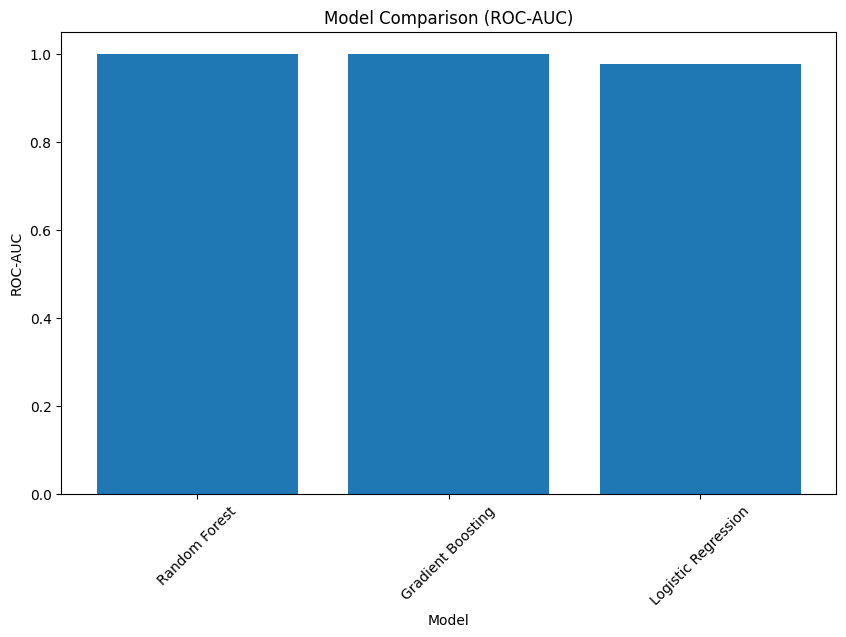

In [59]:
import matplotlib.pyplot as plt

results_df_sorted = results_df.sort_values("ROC-AUC", ascending=False)

plt.figure(figsize=(10,6))

plt.bar(results_df_sorted["Model"], results_df_sorted["ROC-AUC"])

plt.title("Model Comparison (ROC-AUC)")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")

plt.xticks(rotation=45)

plt.show()

In [60]:
best_model_name = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).iloc[0]["Model"]

print("Best model:", best_model_name)

Best model: Random Forest


In [61]:
best_model = models[best_model_name]

In [62]:
#Reentrenando modelo 
best_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [63]:
#Calculando probabilidades
y_prob = best_model.predict_proba(X_test)[:,1]

In [64]:
# Obtener mejor modelo
best_model_name = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).iloc[0]["Model"]

print("Best model:", best_model_name)

# Recuperarlo
best_model = models[best_model_name]

# Entrenarlo
best_model.fit(X_train, y_train)

# Probabilidades
y_prob = best_model.predict_proba(X_test)[:,1]

Best model: Random Forest


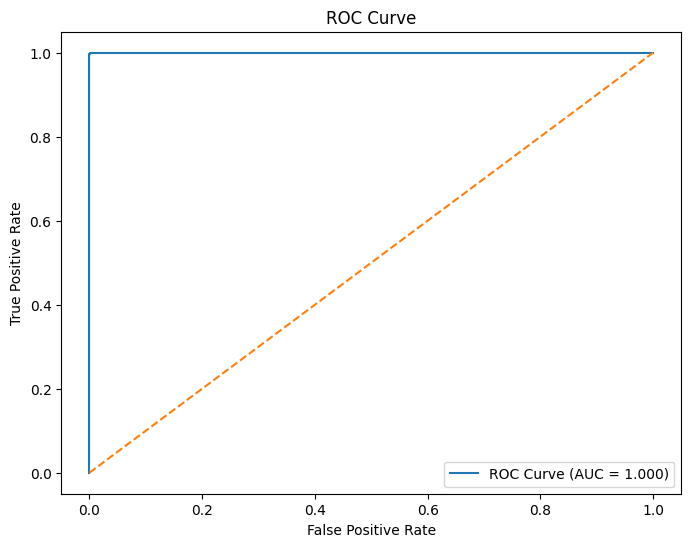

In [65]:
#Curva ROC

from sklearn.metrics import roc_curve, roc_auc_score

y_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_score(y_test,y_prob):.3f})")
plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [66]:
#Haciendo predicciones
y_pred = best_model.predict(X_test)

# Confusión de Matrix

In [67]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[9390    1]
 [   0  609]]


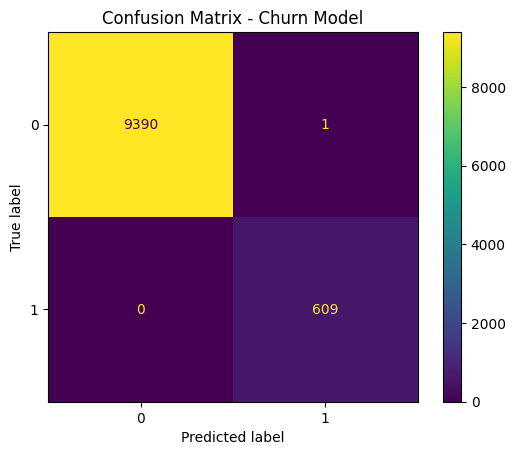

In [68]:
# Visualizando 
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix - Churn Model")

plt.show()

True Negative (TN): clientes correctamente identificados como no churn

True Positive (TP): clientes correctamente identificados como churn

False Positive (FP): clientes predichos como churn pero que no lo son

False Negative (FN): clientes que churnearon pero el modelo no detectó

En churn prediction lo más importante suele ser reducir FN, porque:

un cliente que se va sin ser detectado no puede ser retenido.

# Feature Importance 

In [69]:
import pandas as pd

importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_model.feature_importances_
})

In [70]:
#Ordenando Variables 
importance = importance.sort_values(
    by="importance",
    ascending=False
)

importance.head(10)

,feature,importance
20,engagement_score,0.201332
19,days_since_last_purchase,0.197514
22,inactivity_score,0.175772
23,risk_score,0.110623
9,email_open_rate,0.047857
27,inactivity_ratio,0.045482
26,engagement_per_session,0.031377
3,session_duration_avg,0.025394
5,mobile_app_usage,0.025324
2,login_frequency,0.017842


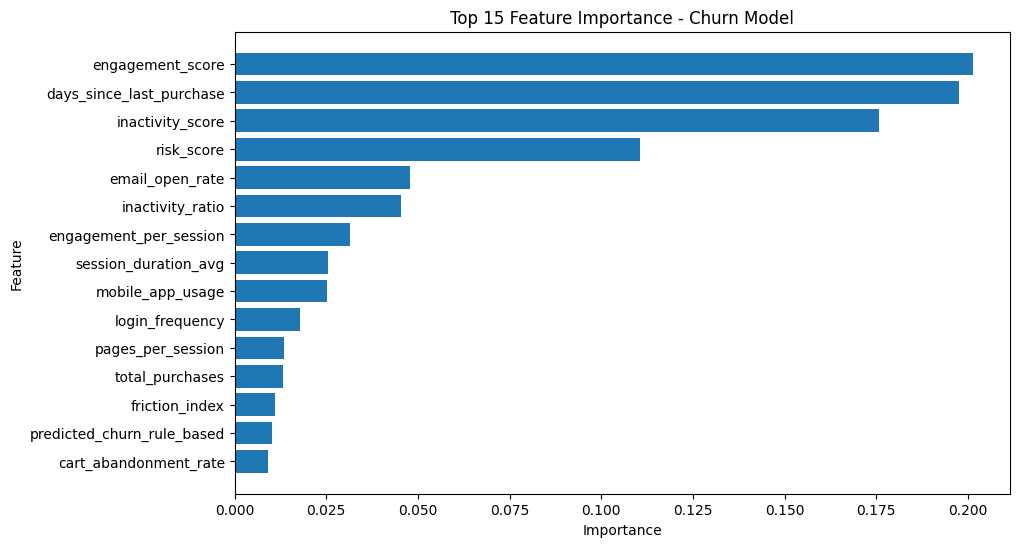

In [71]:
#Visualizando
import matplotlib.pyplot as plt

top_features = importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Feature Importance - Churn Model")

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

Los factores más importantes que impulsan la pérdida de clientes están relacionados con:

• inactividad del cliente
• nivel de interacción
• abandono del carrito de compra

Esto sugiere que los usuarios desconectados con menor actividad tienen una probabilidad significativamente mayor de abandonar el carrito.

## SHAP

In [72]:
# Importando libreria
import shap

In [73]:
X_train.dtypes

age                                 float64
membership_years                    float64
login_frequency                     float64
session_duration_avg                float64
pages_per_session                   float64
mobile_app_usage                    float64
wishlist_items                      float64
product_reviews_written             float64
social_media_engagement_score       float64
email_open_rate                     float64
total_purchases                     float64
average_order_value                 float64
payment_method_diversity            float64
lifetime_value                      float64
credit_balance                      float64
discount_usage_rate                 float64
returns_rate                        float64
customer_service_calls              float64
cart_abandonment_rate               float64
days_since_last_purchase            float64
engagement_score                    float64
friction_index                      float64
inactivity_score                

Auqnue scikit-learn puede trabajar con bool, SHAP  a veces falla si hay tipos mezclados (float64 + bool). En este caso , la solución es convertir todo a numérerico (0 y 1) 

In [74]:
#Convertir boleanos a enteros
X_train = X_train.astype(float)
X_test = X_test.astype(float)

In [75]:
#Creando explainer
import shap

explainer = shap.TreeExplainer(best_model)

In [76]:
#Calcular valores SHAP
shap_values = explainer.shap_values(X_test)

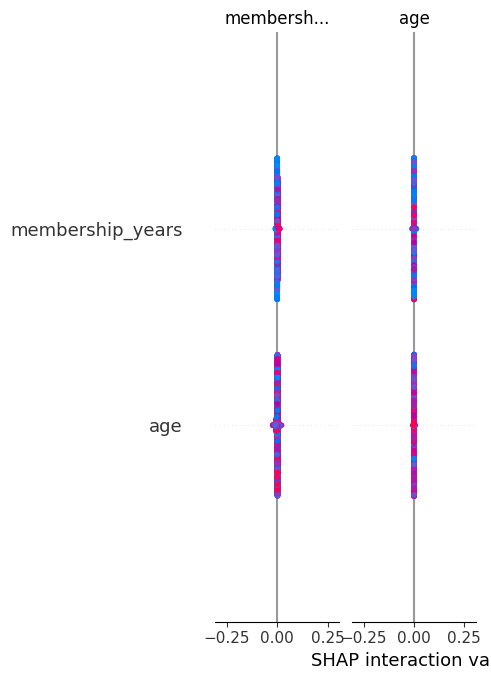

In [77]:
# Visualización

shap.summary_plot(shap_values, X_test)

Este gráfico nos muestra las variables mas importantes, el impacto positivo o negativo en churn y la distrubución de valores
Su interpretación:
rojo --> valor alto de la variable
azul --> valor bajo

derecha --> aumenta churn
izquierda --> reduce churn

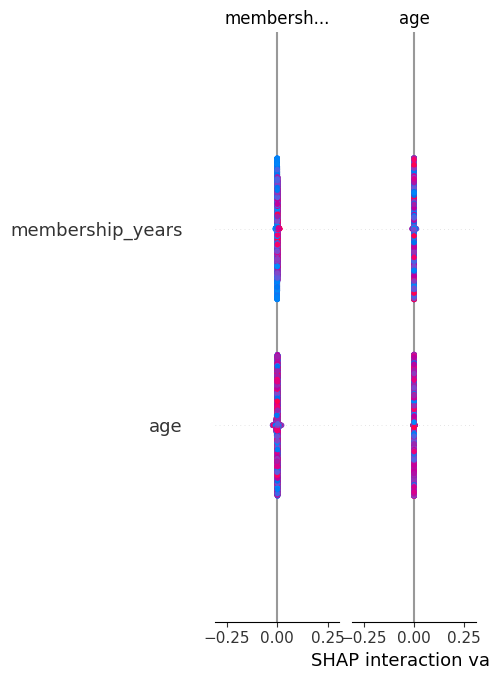

In [78]:
#SHAP Feature Importance
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [79]:
# Explicar un cliente específico 
shap_values_class1 = shap_values[1]

In [80]:
#Recalculando SHAP
import shap

explainer = shap.Explainer(best_model, X_train)

shap_values = explainer(
    X_test,
    check_additivity=False
)

100%|===================| 19992/20000 [13:58<00:00]        

In [81]:
shap_values_churn = shap_values[:,:,1]

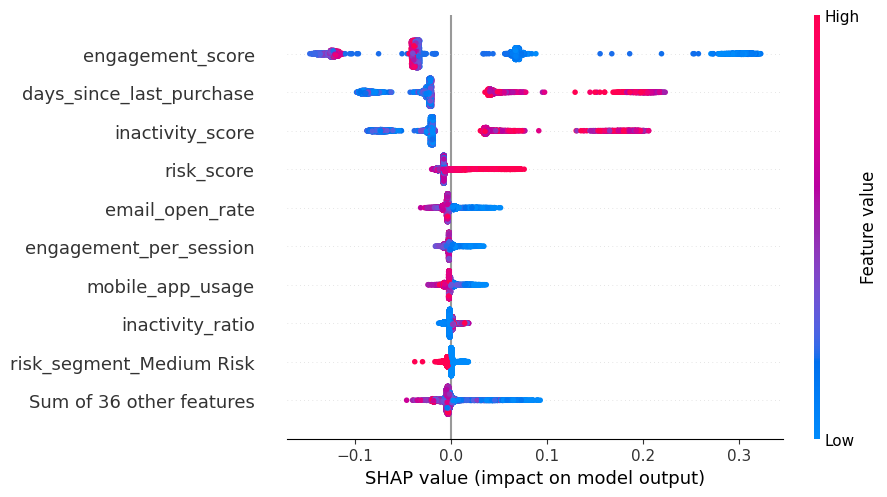

In [82]:
# Shap Summary Plot
shap.plots.beeswarm(shap_values_churn)

Este grafico igualmente muestra las variables más importantes, el impacto positivo o negativo en churn y la distribucion de valores.
Su interpretación:
rojo --> valor alto de la variable
azul --> valor bajo
derecha --> aumenta churn
izquierda --> reduce churn

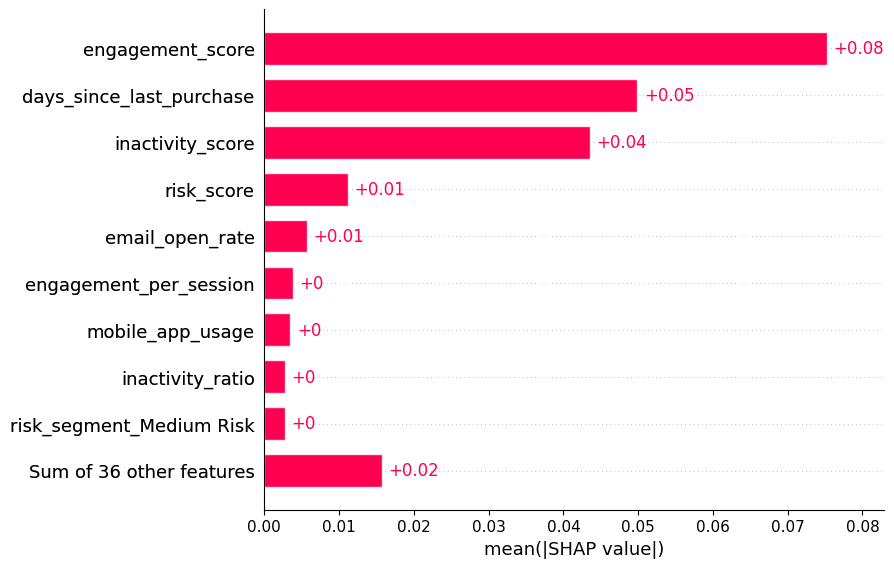

In [83]:
# SHAP FEATURE IMPORTANCE
# Ranking global de variables 
shap.plots.bar(shap_values_churn)

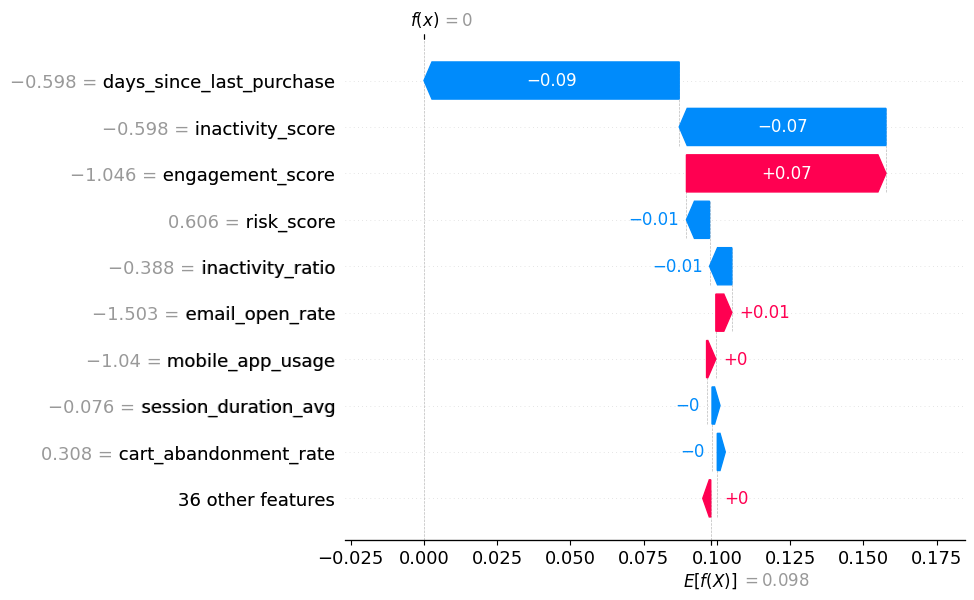

In [84]:
# Explicar un cliente 
shap.plots.waterfall(shap_values_churn[0])

Esto muestra: 
probabilidad base
+ impacto de variables
= predicción final

Ejemplo conceptual: 
inactivity_score ↑ churn
cart_abandonment_rate ↑ churn
engagement_score ↓ churn

In [85]:
#Obtener probabilidad de churn
#Primero sacamos la probabibilidad del modelo 

df_results = X_test.copy()

df_results["churn_probability"] = best_model.predict_proba(X_test)[:,1]

df_results["actual_churn"] = y_test.values

Creando segmentos de riesgo 

Definimos reglas simples de negocio:

Low Risk → < 30%

Medium Risk → 30–60%

High Risk → > 60%

In [86]:
def risk_segment(prob):
    
    if prob < 0.30:
        return "Low Risk"
    
    elif prob < 0.60:
        return "Medium Risk"
    
    else:
        return "High Risk"

df_results["risk_segment"] = df_results["churn_probability"].apply(risk_segment)

In [87]:
# Ver distribución de segmentos 
df_results["risk_segment"].value_counts()

risk_segment
Low Risk       9389
High Risk       610
Medium Risk       1
Name: count, dtype: int64

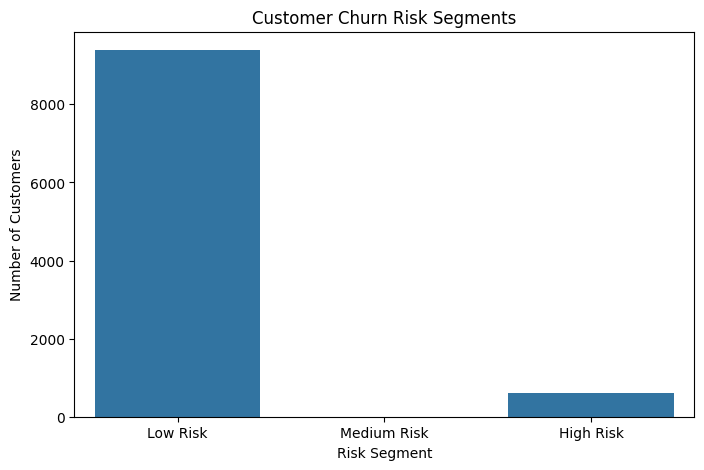

In [88]:
# Visualizar segmnetos de riesgo 
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(
    data=df_results,
    x="risk_segment",
    order=["Low Risk","Medium Risk","High Risk"]
)

plt.title("Customer Churn Risk Segments")
plt.xlabel("Risk Segment")
plt.ylabel("Number of Customers")

plt.show()

Insight de negocio

High Risk customers → target retention campaign
Medium Risk → engagement campaign
Low Risk → loyalty program

In [89]:
high_risk = df_results[df_results["risk_segment"]=="High Risk"]

high_risk.head()

,age,membership_years,login_frequency,session_duration_avg,pages_per_session,mobile_app_usage,wishlist_items,product_reviews_written,social_media_engagement_score,email_open_rate,...,customer_value_tier_medium_value,customer_value_tier_high_value,risk_segment_Low Risk,risk_segment_Medium Risk,signup_quarter_Q2,signup_quarter_Q3,signup_quarter_Q4,churn_probability,actual_churn,risk_segment
10822,-1.630851,-0.769279,-0.720134,-0.762327,-0.768988,-1.106912,-1.069915,-0.794865,-0.080417,-1.308515,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.975,1,High Risk
41252,-1.110721,0.639114,-0.592102,-0.924276,-1.069210,0.347425,-0.743175,0.977824,-0.183999,-0.991742,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.795,1,High Risk
37213,0.016228,-0.720713,-0.592102,-1.095751,-0.086666,-1.185222,-1.069915,-1.238037,0.453028,-0.890951,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.955,1,High Risk
48492,-0.503902,0.153462,-1.488322,-0.076425,-1.205674,-1.319468,-0.089697,-0.794865,-1.095517,-0.264605,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.905,1,High Risk
29600,-0.763967,-0.137930,-0.976197,-0.752800,-0.796281,-0.077689,-0.743175,0.091480,-0.080417,-0.797359,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.880,1,High Risk


Distribución de probabilidades

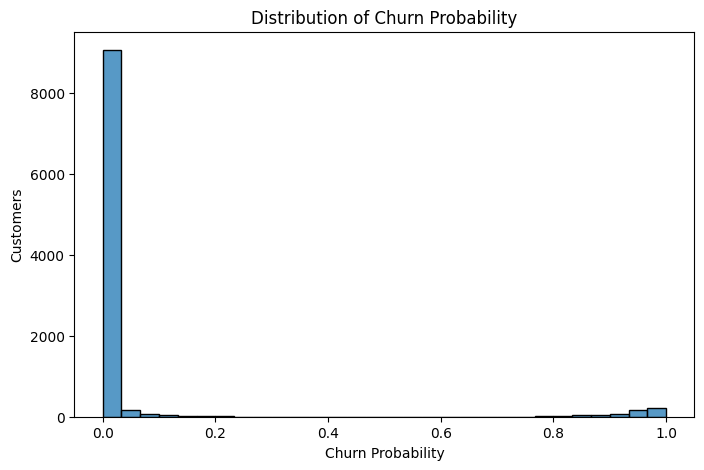

In [90]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_results["churn_probability"],
    bins=30
)

plt.title("Distribution of Churn Probability")
plt.xlabel("Churn Probability")
plt.ylabel("Customers")

plt.show()

TOP CHURN DRIVERS DASHBOARD

In [91]:
# Extraer importancias 

import pandas as pd

feature_importance = pd.DataFrame({
    
    "feature": X_train.columns,
    "importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

In [92]:
# Top 15 variables

top_features = feature_importance.head(15)

top_features

,feature,importance
20,engagement_score,0.201332
19,days_since_last_purchase,0.197514
22,inactivity_score,0.175772
23,risk_score,0.110623
9,email_open_rate,0.047857
27,inactivity_ratio,0.045482
26,engagement_per_session,0.031377
3,session_duration_avg,0.025394
5,mobile_app_usage,0.025324
2,login_frequency,0.017842


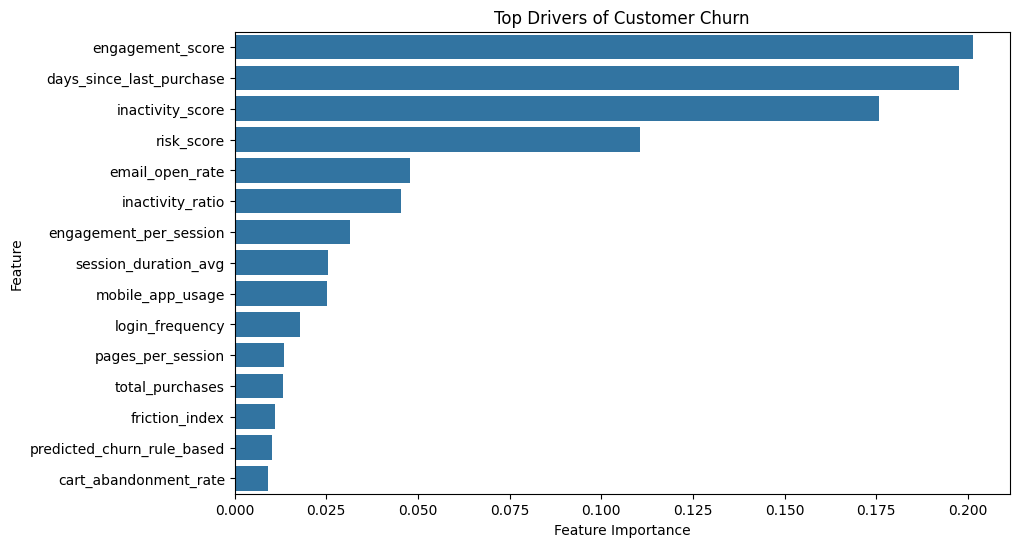

In [93]:
#Grafico de drivers de churn

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="importance",
    y="feature"
)

plt.title("Top Drivers of Customer Churn")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

Esto responde porque los clientes hacen churn:
1 inactivity_score
2 cart_abandonment_rate
3 engagement_score
4 days_since_last_purchase
5 discount_dependency

In [94]:
#Analizar High Risk Customers
#Comportamiento de clientes con alto riesgo 

high_risk = df_results[df_results["risk_segment"]=="High Risk"]

high_risk.describe()

,age,membership_years,login_frequency,session_duration_avg,pages_per_session,mobile_app_usage,wishlist_items,product_reviews_written,social_media_engagement_score,email_open_rate,...,country_USA,customer_value_tier_medium_value,customer_value_tier_high_value,risk_segment_Low Risk,risk_segment_Medium Risk,signup_quarter_Q2,signup_quarter_Q3,signup_quarter_Q4,churn_probability,actual_churn
count,610.000000,610.000000,610.000000,610.000000,610.000000,610.000000,610.000000,610.000000,610.000000,610.000000,...,610.000000,610.000000,610.000000,610.0,610.000000,610.000000,610.000000,610.000000,610.000000,610.000000
mean,-0.035074,-0.094289,-0.923515,-1.029988,-0.910240,-1.024255,-0.795668,-0.696786,-0.726546,-0.969448,...,0.368852,0.209836,0.077049,0.0,0.003279,0.229508,0.259016,0.272131,0.930361,0.998361
std,1.007965,0.972322,0.529433,0.579947,0.584104,0.595510,0.526328,0.526983,0.679573,0.522167,...,0.482890,0.407526,0.266888,0.0,0.057213,0.420862,0.438454,0.445422,0.063053,0.040489
min,-2.411046,-1.400627,-1.488322,-2.534240,-2.106339,-2.158509,-1.396654,-1.238037,-1.509844,-1.502898,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.615000,0.000000
25%,-0.763967,-0.817844,-1.488322,-1.400596,-1.342139,-1.462105,-1.069915,-1.238037,-1.452874,-1.502898,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.900000,1.000000
50%,0.016228,-0.332191,-0.976197,-1.048119,-0.905453,-1.073350,-1.069915,-0.794865,-0.800310,-1.099733,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.950000,1.000000
75%,0.688063,0.384147,-0.592102,-0.648010,-0.468767,-0.606284,-0.416436,-0.351693,-0.080417,-0.602976,...,1.000000,0.000000,0.000000,0.0,0.000000,0.000000,1.000000,1.000000,0.975000,1.000000
max,3.050321,3.407335,0.816244,0.542792,0.595656,0.649479,1.217261,1.420996,1.509561,0.613719,...,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


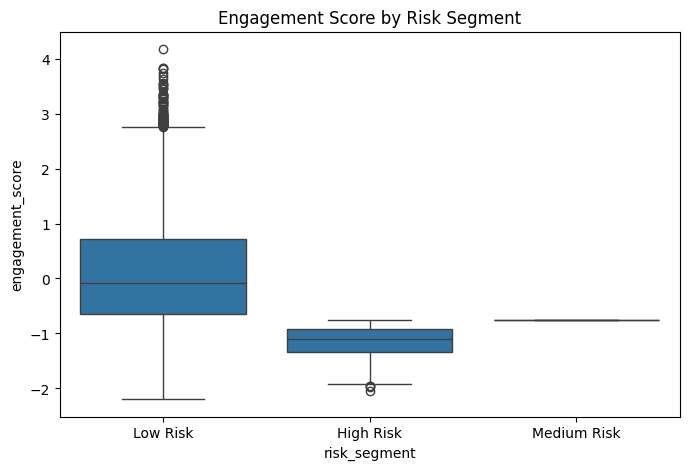

In [95]:
#Comparar segmentos de riesgo
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_results,
    x="risk_segment",
    y="engagement_score"
)

plt.title("Engagement Score by Risk Segment")

plt.show()

In [96]:
retention_actions = {

    "Low Risk": "Loyalty Program",
    "Medium Risk": "Personalized Promotion",
    "High Risk": "Urgent Retention Campaign"
}

df_results["retention_action"] = df_results["risk_segment"].map(retention_actions)

In [97]:
df_results[["churn_probability","risk_segment","retention_action"]].head()

,churn_probability,risk_segment,retention_action
33553,0.0,Low Risk,Loyalty Program
9427,0.0,Low Risk,Loyalty Program
199,0.0,Low Risk,Loyalty Program
12447,0.0,Low Risk,Loyalty Program
39489,0.0,Low Risk,Loyalty Program


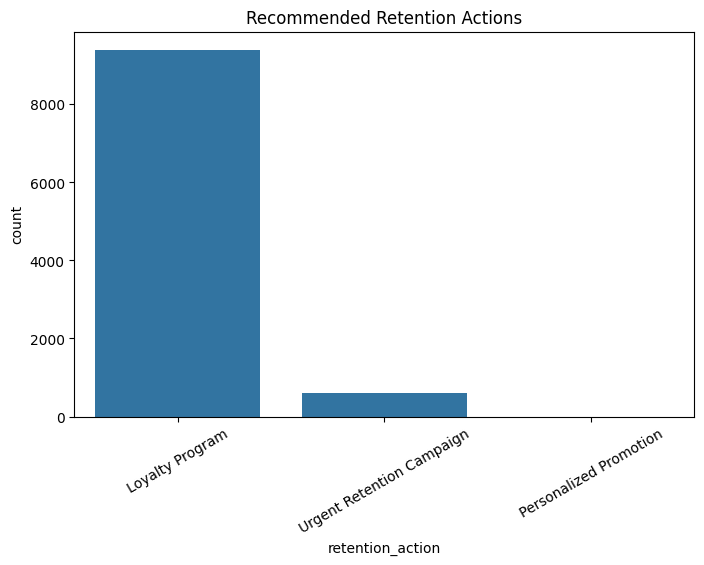

In [98]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_results,
    x="retention_action"
)

plt.title("Recommended Retention Actions")

plt.xticks(rotation=30)

plt.show()

# CREACION DE DATASET PARA POWER BI 

In [99]:
df_results = X_test.copy()

df_results["churn_probability"] = best_model.predict_proba(X_test)[:,1]

df_results["actual_churn"] = y_test.values

In [100]:
#Crear Segmentos de Riesgo
def risk_segment(prob):
    
    if prob < 0.3:
        return "Low Risk"
    
    elif prob < 0.6:
        return "Medium Risk"
    
    else:
        return "High Risk"


df_results["risk_segment"] = df_results["churn_probability"].apply(risk_segment)

In [101]:
#Estrategia de retención 

retention_map = {
    "Low Risk": "Loyalty Program",
    "Medium Risk": "Personalized Promotion",
    "High Risk": "Urgent Retention Campaign"
}

df_results["retention_action"] = df_results["risk_segment"].map(retention_map)

In [102]:
#Exportando Dataset para Power BI 

df_results.to_csv("customer_churn_predictions.csv", index=False)

In [103]:
df_results.columns

Index(['age', 'membership_years', 'login_frequency', 'session_duration_avg',
       'pages_per_session', 'mobile_app_usage', 'wishlist_items',
       'product_reviews_written', 'social_media_engagement_score',
       'email_open_rate', 'total_purchases', 'average_order_value',
       'payment_method_diversity', 'lifetime_value', 'credit_balance',
       'discount_usage_rate', 'returns_rate', 'customer_service_calls',
       'cart_abandonment_rate', 'days_since_last_purchase', 'engagement_score',
       'friction_index', 'inactivity_score', 'risk_score',
       'predicted_churn_rule_based', 'value_per_purchase',
       'engagement_per_session', 'inactivity_ratio', 'discount_dependency',
       'gender_Male', 'gender_Other', 'country_Canada', 'country_France',
       'country_Germany', 'country_India', 'country_Japan', 'country_UK',
       'country_USA', 'customer_value_tier_medium_value',
       'customer_value_tier_high_value', 'risk_segment_Low Risk',
       'risk_segment_Medium Risk'

In [104]:
df_results = X_test.copy()

df_results["churn_probability"] = best_model.predict_proba(X_test)[:,1]
df_results["actual_churn"] = y_test.values

In [105]:
def risk_segment(prob):

    if prob < 0.3:
        return "Low Risk"
    
    elif prob < 0.6:
        return "Medium Risk"
    
    else:
        return "High Risk"

df_results["risk_segment"] = df_results["churn_probability"].apply(risk_segment)

In [106]:
retention_map = {
    "Low Risk": "Loyalty Program",
    "Medium Risk": "Personalized Promotion",
    "High Risk": "Urgent Retention Campaign"
}

df_results["retention_action"] = df_results["risk_segment"].map(retention_map)

In [107]:
df_results.to_csv("customer_churn_predictions.csv", index=False)

In [111]:
import pandas as pd

# SHAP values del modelo
shap_df = pd.DataFrame(
    shap_values.values,
    columns=X_test.columns
)

# Añadir probabilidad de churn
shap_df["churn_probability"] = best_model.predict_proba(X_test)[:,1]

# Guardar archivo
shap_df.to_csv("shap_values_powerbi.csv", index=False)

ValueError: Must pass 2-d input. shape=(10000, 45, 2)